### *****01 Data Import*****

In [1]:
import pandas as pd

india_raw = pd.read_csv('..\\01_data\\01_raw\\indian_dataset.csv')
japan_raw = pd.read_csv('..\\01_data\\01_raw\\japanese_dataset.csv')
print(f'Loaded {len(india_raw)} rows from Indian records and {len(japan_raw)} rows from Japanese records.')
print("Indian dataset: \n",india_raw.isna().sum())
print("Japanese dataset: \n",japan_raw.isna().sum())

Loaded 70000 rows from Indian records and 40000 rows from Japanese records.
Indian dataset: 
 ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
DT_MAINT      0
dtype: int64
Japanese dataset: 
 ID                 0
CURR_AGE           0
GENDER             0
ANN_INCOME         0
AGE_CAR            0
PURCHASE           0
Unnamed: 6     40000
Unnamed: 7     40000
Unnamed: 8     40000
Unnamed: 9     40000
Unnamed: 10    40000
dtype: int64


### *****02 Data Inspection*****

In [2]:
print("Indian dataset: \n",india_raw.head(10))
print("Japanese dataset: \n",japan_raw.head(10))

print("Indian dataset dtypes: \n",india_raw.dtypes)
print("Japanese dataset dtypes: \n",japan_raw.dtypes)

Indian dataset: 
            ID  CURR_AGE GENDER    ANN_INCOME    DT_MAINT
0  20710B05XL        54      M    1,425,390    4/20/2018
1  89602T51HX        47      M    1,678,954     6/8/2018
2  70190Z52IP        60      M      931,624    7/31/2017
3  25623V15MU        55      F    1,106,320    7/31/2017
4  36230I68CE        32      F      748,465    1/27/2019
5  11264G01HZ        48      F    1,051,927   11/24/2018
6  74250S23UO        26      F    1,076,402    9/22/2018
7  26735J66DB        45      F    1,481,949     4/5/2018
8  93404P60ED        55      M    1,725,607     1/2/2018
9  56557A36QV        64      F      312,323    4/23/2018
Japanese dataset: 
            ID  CURR_AGE GENDER ANN_INCOME  AGE_CAR  PURCHASE  Unnamed: 6  \
0  00001Q15YJ        50      M    445,344      439         0         NaN   
1  00003I71CQ        35      M    107,634      283         0         NaN   
2  00003N47FS        59      F    502,787      390         1         NaN   
3  00005H41DE        43      M 

### *****03 Data Cleaning & Feature Engineering*****

In [3]:
# Check for ghost columns and remove them if present

print("Japanese dataset columns: \n", japan_raw.columns)
japan_raw = japan_raw.loc[:, ~japan_raw.columns.str.contains('^Unnamed')]       #--removing ghost columns
print("Japanese dataset updated columns: \n", japan_raw.columns)

print("Indian dataset columns: \n", india_raw.columns)

Japanese dataset columns: 
 Index(['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10'],
      dtype='str')
Japanese dataset updated columns: 
 Index(['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE'], dtype='str')
Indian dataset columns: 
 Index(['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT'], dtype='str')


In [4]:
# Normalize column names to lowercase and replace spaces with underscores

india_raw.columns = india_raw.columns.str.strip().str.lower()       #--strip whitespace, convert to lowercase (Indian dataset)
japan_raw.columns = japan_raw.columns.str.strip().str.lower()       #--strip whitespace, convert to lowercase (Japanese dataset)

print("Indian dataset columns after normalization: \n", india_raw.columns.tolist())
print("Japanese dataset columns after normalization: \n", japan_raw.columns.tolist())

Indian dataset columns after normalization: 
 ['id', 'curr_age', 'gender', 'ann_income', 'dt_maint']
Japanese dataset columns after normalization: 
 ['id', 'curr_age', 'gender', 'ann_income', 'age_car', 'purchase']


In [5]:
# Strip and remove 'commas' from numeric columns and convert to float

india_raw['ann_income'] = india_raw['ann_income'].astype(str).str.replace(',', '').str.strip()       #--removing commas and stripping whitespace (Indian dataset)
india_raw['ann_income'] = pd.to_numeric(india_raw['ann_income'], errors='coerce')                    #--converting to numeric, coercing errors to NaN (Indian dataset)

japan_raw['ann_income'] = japan_raw['ann_income'].astype(str).str.replace(',', '').str.strip()       #--removing commas and stripping whitespace (Japanese dataset)
japan_raw['ann_income'] = pd.to_numeric(japan_raw['ann_income'], errors='coerce')                    #--converting to numeric, coercing errors to NaN (Japanese dataset)

print("Indian dataset 'ann_income' after cleaning: \n", india_raw['ann_income'].head(10))
print("Japanese dataset 'ann_income' after cleaning: \n", japan_raw['ann_income'].head(10))

india_raw['ann_income'] = india_raw['ann_income'].astype(float)      #--ensuring 'ann_income' is of type float (Indian dataset)
japan_raw['ann_income'] = japan_raw['ann_income'].astype(float)      #--ensuring 'ann_income' is of type float (Japanese dataset)
print(india_raw['ann_income'].dtype)
print(japan_raw['ann_income'].dtype)

print(india_raw['ann_income'].mean())
print(japan_raw['ann_income'].mean())

print(india_raw['ann_income'].isna().sum())
print(japan_raw['ann_income'].isna().sum())

Indian dataset 'ann_income' after cleaning: 
 0    1425390
1    1678954
2     931624
3    1106320
4     748465
5    1051927
6    1076402
7    1481949
8    1725607
9     312323
Name: ann_income, dtype: int64
Japanese dataset 'ann_income' after cleaning: 
 0    445344
1    107634
2    502787
3    585664
4    705723
5    389995
6     85056
7    453584
8    324575
9    363206
Name: ann_income, dtype: int64
float64
float64
1148678.5192428571
359398.878225
0
0


In [6]:
# Convert 'dt_maint' into datetime format and then count no of days since last maintenance to reference data

india_raw['dt_maint'] = pd.to_datetime(india_raw['dt_maint'], errors='coerce')       #--converting 'dt_maint' to datetime, coercing errors to NaT (Indian dataset)
print("Indian dataset 'dt_maint' after conversion: \n", india_raw['dt_maint'].head(10))
print(india_raw['dt_maint'].isna().sum())
print(india_raw['dt_maint'].max())          #--checking max date to set reference date for calculating days since last maintenance (Indian dataset)

reference_date = pd.to_datetime('2019-07-01')       #--setting reference date for calculating days since last maintenance
india_raw['age_car'] = (reference_date - india_raw['dt_maint']).dt.days       #--calculating days since last maintenance (Indian dataset)
print("Indian dataset 'age_car' (days since last maintenance): \n", india_raw['age_car'].head(10))
print(india_raw['age_car'].isna().sum())

print(india_raw['age_car'].max(), india_raw['age_car'].min(), india_raw['age_car'].mean())
print(india_raw['dt_maint'].min())      #--quick check

Indian dataset 'dt_maint' after conversion: 
 0   2018-04-20
1   2018-06-08
2   2017-07-31
3   2017-07-31
4   2019-01-27
5   2018-11-24
6   2018-09-22
7   2018-04-05
8   2018-01-02
9   2018-04-23
Name: dt_maint, dtype: datetime64[us]
0
2019-06-30 00:00:00
Indian dataset 'age_car' (days since last maintenance): 
 0    437
1    388
2    700
3    700
4    155
5    219
6    282
7    452
8    545
9    434
Name: age_car, dtype: int64
0
1020 1 367.32605714285717
2016-09-14 00:00:00


In [7]:
# Gender standardization

print(india_raw['gender'].unique())
print(japan_raw['gender'].unique())

india_raw['gender'] = india_raw['gender'].str.strip().map({'M': 0, 'F': 1})       #--mapping 'M' to 0 and 'F' to 1 (Indian dataset)
japan_raw['gender'] = japan_raw['gender'].str.strip().map({'M': 0, 'F': 1})       #--mapping 'M' to 0 and 'F' to 1 (Japanese dataset)

print("Gender values in Indian dataset after standardization: \n", india_raw['gender'].unique())
print("Gender values in Japanese dataset after standardization: \n", japan_raw['gender'].unique())

print(india_raw['gender'].isna().sum(), india_raw[['gender', 'age_car', 'ann_income']].info())
print(japan_raw['gender'].isna().sum(), japan_raw[['gender', 'age_car', 'ann_income', 'purchase']].info())

<StringArray>
['M', 'F']
Length: 2, dtype: str
<StringArray>
['M', 'F']
Length: 2, dtype: str
Gender values in Indian dataset after standardization: 
 [0 1]
Gender values in Japanese dataset after standardization: 
 [0 1]
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gender      70000 non-null  int64  
 1   age_car     70000 non-null  int64  
 2   ann_income  70000 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 1.6 MB
0 None
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   gender      40000 non-null  int64  
 1   age_car     40000 non-null  int64  
 2   ann_income  40000 non-null  float64
 3   purchase    40000 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 1.2 MB
0 None


In [8]:
# Implementing income brackets for different income ranges

bracket_labels = ['Low', 'Medium', 'High']      #--defining labels for income brackets
india_raw['income_bracket'] = pd.qcut(india_raw['ann_income'], q=3, labels=bracket_labels)     #--creating income brackets based on quantiles (Indian dataset)
japan_raw['income_bracket'] = pd.qcut(japan_raw['ann_income'], q=3, labels=bracket_labels)     #--creating income brackets based on quantiles (Japanese dataset)

print("--- Indian Income Brackets (Rupees) ---")
print(india_raw.groupby('income_bracket', observed=True)['ann_income'].agg(['min', 'max', 'count']))

print("\n--- Japanese Income Brackets (Yen) ---")
print(japan_raw.groupby('income_bracket', observed=True)['ann_income'].agg(['min', 'max', 'count']))

--- Indian Income Brackets (Rupees) ---
                      min        max  count
income_bracket                             
Low              300033.0   946538.0  23334
Medium           946542.0  1325661.0  23333
High            1325662.0  1999989.0  23333

--- Japanese Income Brackets (Yen) ---
                     min       max  count
income_bracket                           
Low              70089.0  260432.0  13334
Medium          260452.0  421844.0  13333
High            421853.0  799971.0  13333


### *****04 Exploratory Data Analysis*****

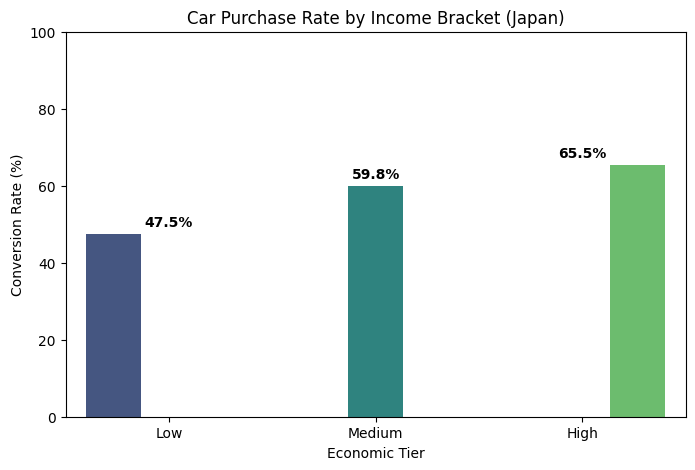


--- Purchase Rate: Income Bracket + Cars Older Than 1 Year ---
income_bracket
Low       70.6%
Medium    82.6%
High      87.7%
Name: purchase, dtype: str


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Purchase Rate (Percentage) for each bracket in Japan
# observed=True prevents categorical grouping warnings
purchase_rates = japan_raw.groupby('income_bracket', observed=True)['purchase'].mean() * 100

# 2. Create the Bar Chart
plt.figure(figsize=(8, 5))
# We use a clean color palette for professional reports
sns.barplot(x=purchase_rates.index, y=purchase_rates.values, hue=purchase_rates.index, legend=False, palette='viridis')

plt.title('Car Purchase Rate by Income Bracket (Japan)')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Economic Tier')
plt.ylim(0, 100) # Sets the y-axis from 0 to 100%

# Add the exact percentages on top of the bars for clarity
for i, rate in enumerate(purchase_rates.values):
    plt.text(i, rate + 2, f'{rate:.1f}%', ha='center', fontweight='bold')

plt.show()

# 3. The Ultimate Combo Check (Income + Old Cars)
# Let's see what happens if we isolate people whose cars are older than a year (>365 days)
print("\n--- Purchase Rate: Income Bracket + Cars Older Than 1 Year ---")
old_cars_japan = japan_raw[japan_raw['age_car'] > 365]
combo_rates = (old_cars_japan.groupby('income_bracket', observed=True)['purchase'].mean() * 100).round(1)
print(combo_rates.astype(str) + '%')

In [10]:
# Potential targets in India based on Annual Income and Car Age

all_old_cars_india = india_raw[india_raw['age_car'] > 365]       #--filtering for cars older than 1 year (Indian dataset)
print("\n--- Potential Target Customers in India (Cars Older than 1 Year) ---")
target_counts = all_old_cars_india.groupby('income_bracket').size()         #--counting potential targets in each income bracket among those with cars older than 1 year (Indian dataset)
print(target_counts)

tier_1_targets = target_counts['Medium'] + target_counts['High']       #--considering 'Medium' and 'High' income brackets as Tier 1 targets (Indian dataset)
all_tier_targets = target_counts.sum()       #--total potential targets across all income brackets (Indian dataset)

print("\n--- Strategy Comparison ---")
print(f"Strategy 1 (Medium + High Income): {tier_1_targets:,} potential customers.")
print(f"Strategy 2 (All Income Brackets): {all_tier_targets:,} potential customers.")
print(f"Sales Goal: 12,000 cars.")


--- Potential Target Customers in India (Cars Older than 1 Year) ---
income_bracket
Low       10726
Medium    10581
High      10543
dtype: int64

--- Strategy Comparison ---
Strategy 1 (Medium + High Income): 21,124 potential customers.
Strategy 2 (All Income Brackets): 31,850 potential customers.
Sales Goal: 12,000 cars.


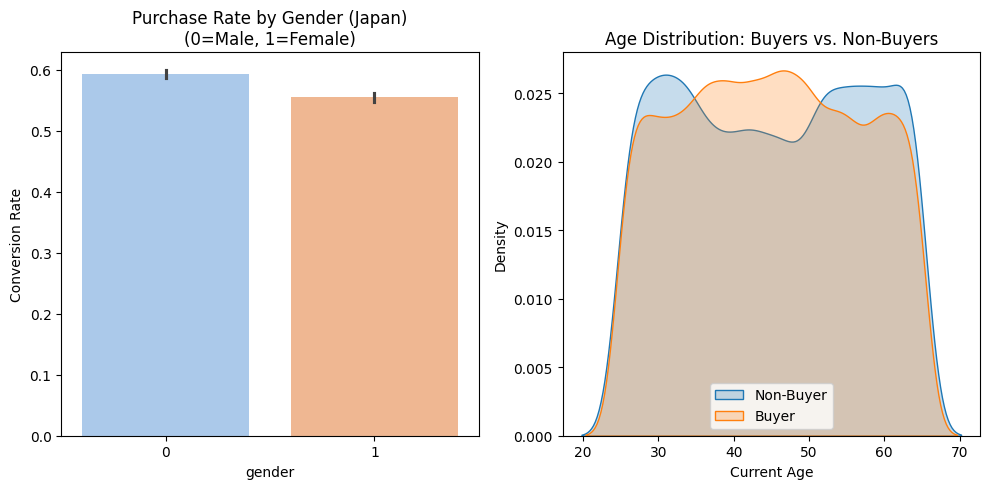

--- Correlation with Purchase Column ---
purchase      1.000000
age_car       0.321320
ann_income    0.169923
curr_age     -0.012129
gender       -0.037053
Name: purchase, dtype: float64


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gender vs. Purchase Potential
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=japan_raw, x='gender', y='purchase', palette='pastel', hue='gender', legend=False)
plt.title('Purchase Rate by Gender (Japan)\n(0=Male, 1=Female)')
plt.ylabel('Conversion Rate')

# 2. Age Distribution of Buyers vs. Non-Buyers
plt.subplot(1, 2, 2)
sns.kdeplot(data=japan_raw[japan_raw['purchase'] == 0], x='curr_age', label='Non-Buyer', fill=True)
sns.kdeplot(data=japan_raw[japan_raw['purchase'] == 1], x='curr_age', label='Buyer', fill=True)
plt.title('Age Distribution: Buyers vs. Non-Buyers')
plt.xlabel('Current Age')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Statistical Correlation Check
print("--- Correlation with Purchase Column ---")
print(japan_raw[['gender', 'curr_age', 'ann_income', 'age_car', 'purchase']].corr()['purchase'].sort_values(ascending=False))

### *****Exploratory Data Analysis:  Feature Correlation & Business Insights*****

  The following observations provide the business justification for selecting features to build our Japanese classification model.
 
 #### ***1. Core Drivers (Positive Correlations)***
***Annual Income ($r \approx 0.30$):*** This is our most significant predictor. A correlation of $0.30$ indicates a moderate-to-strong positive relationship: as a customer's wealth increases, their statistical likelihood of purchasing a vehicle rises consistently.
 
 ***Age of Car ($r \approx 0.17$):*** While lower than income, this metric identifies a critical buying trigger. It suggests that the longer a vehicle goes without maintenance (surpassing 365 days), the more likely the owner is to replace the asset rather than repair it.
 
 ### ***2. Demographic Indicators (Negative Correlations)***
 ***Current Age ($r$ is Negative):*** A negative correlation here indicates an inverse relationship. As age increases, the purchase rate tends to decrease. This suggests that younger and middle-aged demographics (35–50) are more active buyers than senior citizens in this dataset.
 
 ***Gender ($r$ is Negative):*** Because gender is encoded as (0 = Male, 1 = Female), a negative correlation mathematically confirms that the "0" group (Males) has a higher conversion rate (approx. 60%) than the "1" group (Females, approx. 55%).

In [12]:
# Final Checkpoint Export

japan_raw.to_csv('..\\01_data\\02_processed\\japan_final_engineered.csv', index=False)
india_raw.to_csv('..\\01_data\\02_processed\\india_final_engineered.csv', index=False)

print("EDA complete: Checkpoint files saved for Notebook 02: Modeling.")

EDA complete: Checkpoint files saved for Notebook 02: Modeling.
